Final Estimated Ratings: [2.8721241  3.43055388 4.47085454]
Number of visits: [ 26.  31. 443.]


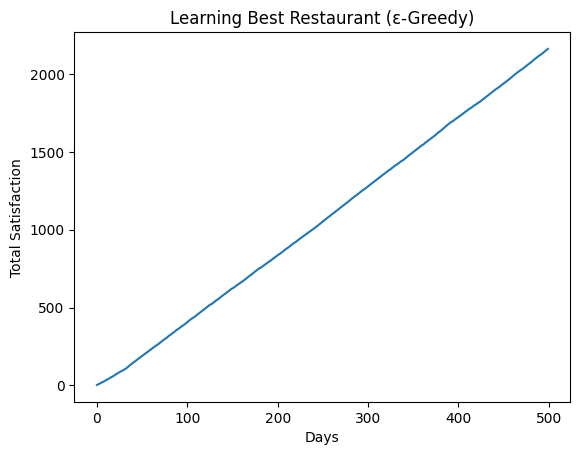

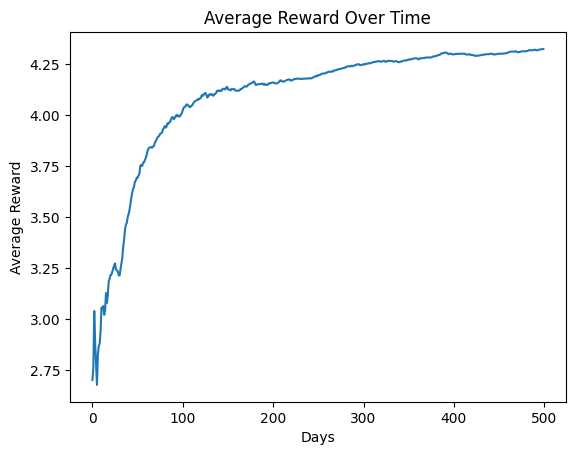

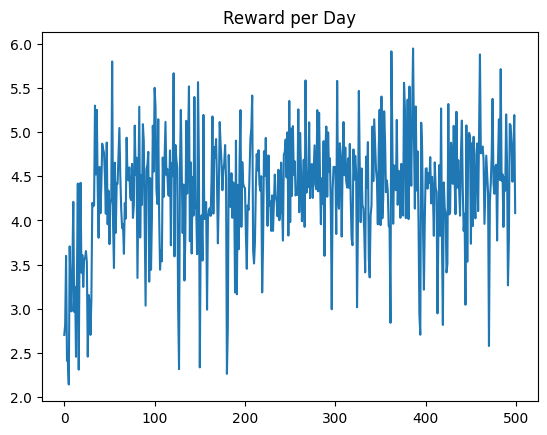

In [ ]:
#Example:1

import numpy as np
import matplotlib.pyplot as plt
restaurants = ["A", "B", "C"]
k = len(restaurants)
#Below line only for simulation of reality
true_means = [3.0, 3.5, 4.5]
#Q: Estimated Value
#(Intiially Agent’s belief about each restaurant is 0)
Q = np.zeros(k)
#N: Count of Visits→ Number of times each restaurant is tried
N = np.zeros(k)
# Epsilon (ε) is a parameter that controls exploration
# the belo epsilon value means 10% of the time explore, 90% → Exploit
epsilon = 0.1
# Total number of Trials = days
days = 500
# total_reward → cumulative satisfaction
total_reward = 0
#rewards → used for plotting graph
rewards = []
#choices → stores selected actions
choices = []
# Generates reward randomly
# If action = C, then reward =4.5+ noise, Simulate real-life un-certainty
def get_reward(action):
  return np.random.normal(true_means[action], 0.5)
for day in range(days):
  if np.random.rand() < epsilon:
    action = np.random.randint(k) # Explore
  else:
    action = np.argmax(Q) # Exploit
  reward = get_reward(action)
  N[action] += 1
  # update incremental average
  #Every time the reward value - Q[action]→ already stored / Total no. of times this action was chosen before
  Q[action] += (reward - Q[action]) / N[action]
  total_reward += reward
  rewards.append(total_reward)
  choices.append(action)
# Results
print("Final Estimated Ratings:", Q)
print("Number of visits:", N)
# Plot cumulative reward
plt.plot(rewards)
plt.xlabel("Days")
plt.ylabel("Total Satisfaction")
plt.title("Learning Best Restaurant (ε-Greedy)")
plt.show()

avg_rewards = [rewards[i]/(i+1) for i in range(len(rewards))]
plt.plot(avg_rewards)
plt.xlabel("Days")
plt.ylabel("Average Reward")
plt.title("Average Reward Over Time")
plt.show()

plt.plot([rewards[i] - rewards[i-1] if i>0 else rewards[0] for i in range(len(rewards))])
plt.title("Reward per Day")
plt.show()

Final Value Function (V): [49.99867193 50.99867193]
Optimal Policy: ['C', 'C']


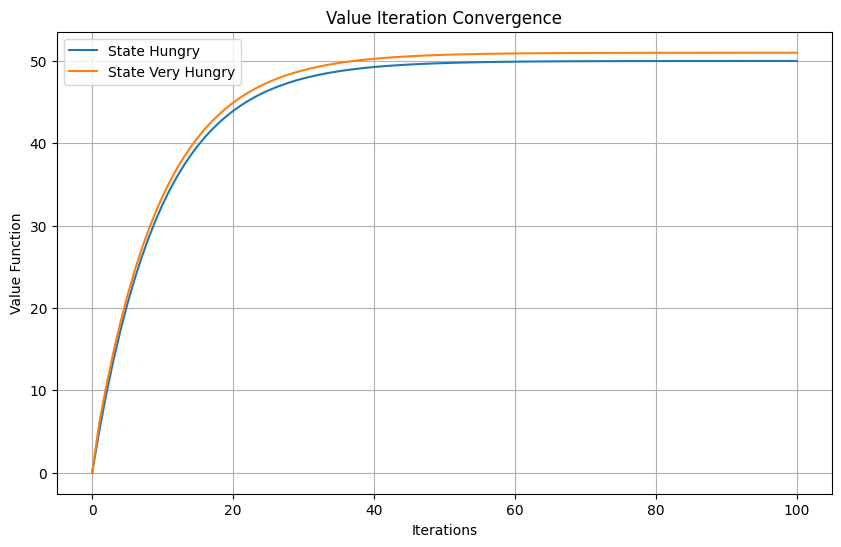


Optimal Policy:
For state 'Hungry': Choose action 'C'
For state 'Very Hungry': Choose action 'C'


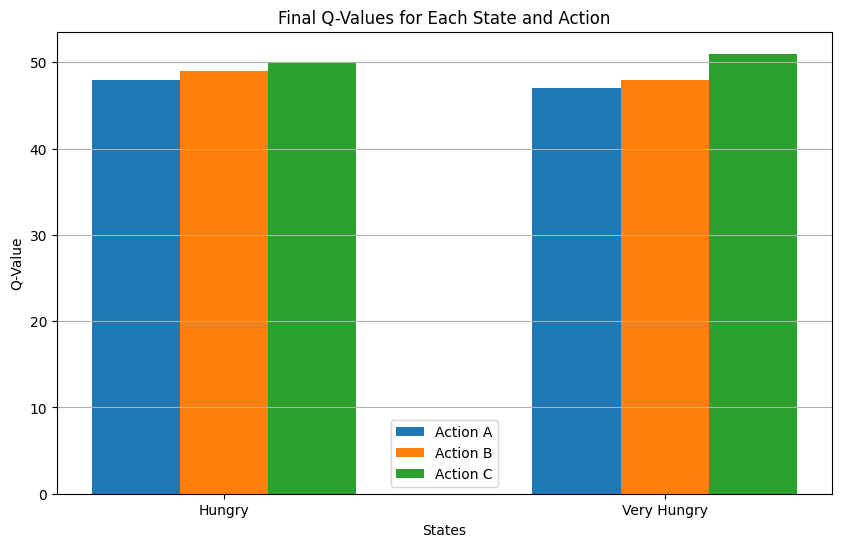

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Example:2

states = ["Hungry", "Very Hungry"]
actions = ["A", "B", "C"]
R = np.array([[3, 4, 5],[2, 3, 6]])

def get_next_state(s, a):
  # As per the original code, this always returns 0 for simplicity.
  # In a general MDP, this would be a transition function p(s'|s,a).
  return 0

n_states = len(states)
V = np.zeros(n_states)

num_iterations = 100 # Define the number of iterations
n_actions = len(actions) # Define the number of actions
gamma = 0.9 # Define the discount factor

V_history = [V.copy()] # To store V at each iteration for plotting
policy = np.zeros(n_states, dtype=int) # To store the optimal policy

for i in range(num_iterations):
  new_V = np.zeros(n_states) # Initialize new_V for current iteration
  for s in range(n_states):
    action_values = []
    for a in range(n_actions):
      next_s_val = get_next_state(s, a) # Simplified next state
      value = R[s][a] + gamma * V[next_s_val]
      action_values.append(value)
    new_V[s] = max(action_values)
    policy[s] = np.argmax(action_values) # Update policy based on current V
  V = np.copy(new_V) # Update V for next iteration
  V_history.append(V.copy())

print("Final Value Function (V):", V)
print("Optimal Policy:", [actions[a] for a in policy])

# Plotting the convergence of V
V_history_array = np.array(V_history)
plt.figure(figsize=(10, 6))
for s_idx, s_name in enumerate(states):
  plt.plot(V_history_array[:, s_idx], label=f'State {s_name}')
plt.xlabel("Iterations")
plt.ylabel("Value Function")
plt.title("Value Iteration Convergence")
plt.legend()
plt.grid(True)
plt.show()

# Print the final policy clearly
print("\nOptimal Policy:")
for s_idx, s_name in enumerate(states):
  print(f"For state '{s_name}': Choose action '{actions[policy[s_idx]]}'")

# Plot the Q-values for each state-action pair to visualize choices
Q_final = np.zeros((n_states, n_actions))
for s in range(n_states):
    for a in range(n_actions):
        next_s_val = get_next_state(s, a)
        Q_final[s, a] = R[s][a] + gamma * V[next_s_val]

plt.figure(figsize=(10, 6))
width = 0.2
x = np.arange(n_states)
for i, action_name in enumerate(actions):
    plt.bar(x + i*width - (n_actions-1)*width/2, Q_final[:, i], width, label=f'Action {action_name}')

plt.xlabel("States")
plt.ylabel("Q-Value")
plt.title("Final Q-Values for Each State and Action")
plt.xticks(x, states)
plt.legend()
plt.grid(axis='y')
plt.show()